# Movie Color-Mood Analysis — Exploration

Interactive analysis and figure generation.

In [2]:
# Source - https://stackoverflow.com/a/66991145
# Posted by R Kumar
# Retrieved 2026-04-27, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


In [3]:
import json
import sys
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.color_extraction import compute_summary_stats
from src.analysis import (
    build_emd_matrix, build_feature_matrix, embed_scenes,
    run_anova, train_mood_classifier,
)
from src.visualization import (
    plot_movie_barcode, plot_palette_strip, plot_polar_hue,
    plot_mood_timeline, plot_embedding,
)

%matplotlib inline
sns.set_theme(style="whitegrid")

## Load Data

Update the paths below to point to your pipeline outputs.

In [4]:
FILM = "spiderman"  # Change this
BASE_DIR = os.path.dirname( os.getcwd())
OUTPUT_DIR = os.path.join( BASE_DIR, f"data/outputs/{FILM}")

with open(OUTPUT_DIR + "/palettes.json") as f:
    palettes_data = json.load(f)["palettes"]

with open(BASE_DIR + f"/data/annotations/{FILM}.json") as f:
    annotations = json.load(f)

mood_labels = [s["mood_label"] for s in annotations["scenes"]]
print(f"Loaded {len(palettes_data)} scenes, {len(set(mood_labels))} mood categories")

Loaded 1015 scenes, 8 mood categories


## Movie Barcode

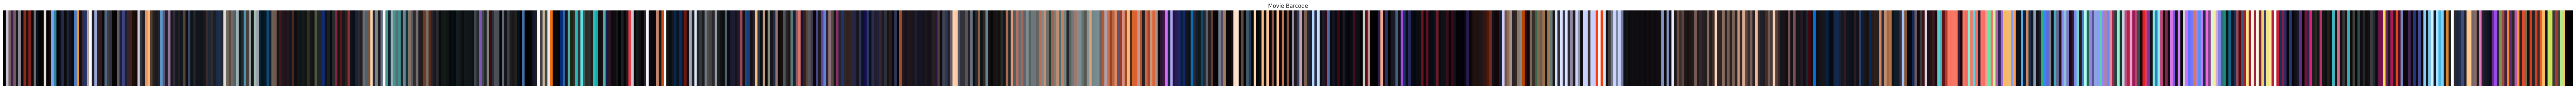

In [5]:
plot_movie_barcode(palettes_data);

## EMD Embedding by Mood

Building EMD matrix: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1015/1015 [00:58<00:00, 17.38it/s]


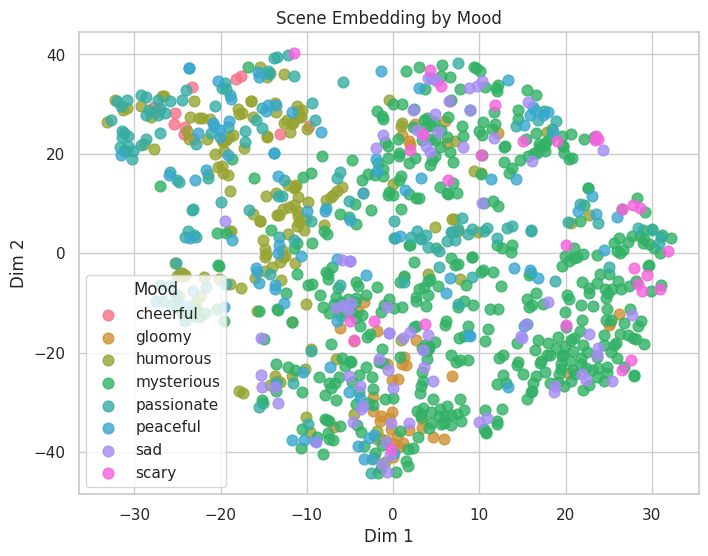

In [6]:
emd_matrix = build_emd_matrix(palettes_data)
coords = embed_scenes(emd_matrix, method="tsne")
plot_embedding(coords, mood_labels);

## Mood Timeline

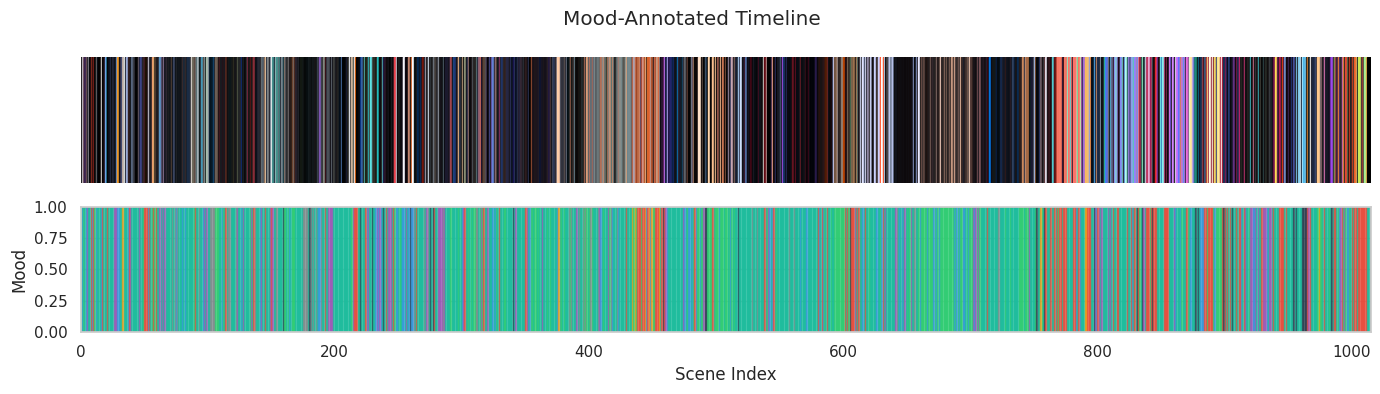

In [7]:
plot_mood_timeline(palettes_data, annotations["scenes"]);

## Mood Classification

Train a random forest on per-scene color features. Reports accuracy, macro-F1, per-class precision/recall/F1, dummy baselines, confusion matrix, and feature importances.

In [8]:
features = build_feature_matrix(palettes_data)
clf_results = train_mood_classifier(features, mood_labels)

print(f"Accuracy:        {clf_results['mean_accuracy']:.2%} ± {clf_results['std_accuracy']:.2%}")
print(f"Macro-F1:        {clf_results['macro_f1']:.3f} ± {clf_results['macro_f1_std']:.3f}")
print(f"Weighted-F1:     {clf_results['weighted_f1']:.3f} ± {clf_results['weighted_f1_std']:.3f}")
print(f"Uniform chance:  {clf_results['chance_baseline']:.2%}")
print(f"Majority class:  {clf_results['majority_baseline']:.2%}")
print(f"Dummy stratified acc/F1: {clf_results['dummy_stratified']['accuracy']:.2%} / {clf_results['dummy_stratified']['macro_f1']:.3f}")
print(f"Dummy majority   acc/F1: {clf_results['dummy_majority']['accuracy']:.2%} / {clf_results['dummy_majority']['macro_f1']:.3f}")


Accuracy:        62.66% ± 0.65%
Macro-F1:        0.336 ± 0.035
Weighted-F1:     0.560 ± 0.015
Uniform chance:  12.50%
Majority class:  46.80%
Dummy stratified acc/F1: 31.72% / 0.131
Dummy majority   acc/F1: 46.80% / 0.080


### Per-Class Report

In [9]:
per_class_df = pd.DataFrame(clf_results['per_class']).T
per_class_df = per_class_df.sort_values('support', ascending=False)
per_class_df


,precision,recall,f1,support
mysterious,0.673134,0.949474,0.787773,475.0
humorous,0.571429,0.615385,0.592593,156.0
passionate,0.525424,0.476923,0.500000,130.0
peaceful,0.333333,0.065934,0.110092,91.0
sad,0.333333,0.039474,0.070588,76.0
gloomy,0.615385,0.363636,0.457143,44.0
scary,0.200000,0.032258,0.055556,31.0
cheerful,1.000000,0.083333,0.153846,12.0


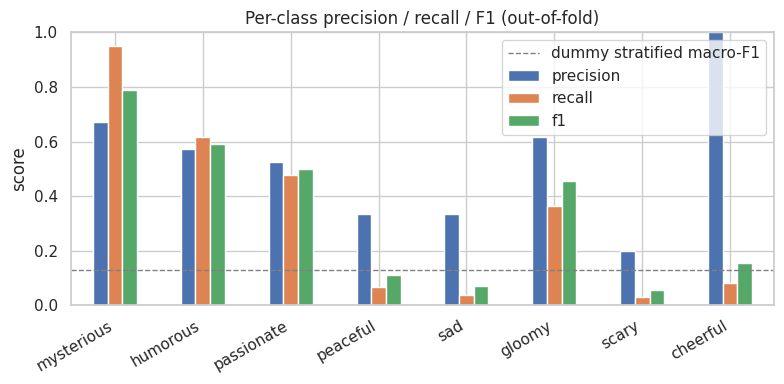

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
per_class_df[['precision', 'recall', 'f1']].plot.bar(ax=ax)
ax.set_title('Per-class precision / recall / F1 (out-of-fold)')
ax.set_ylabel('score')
ax.set_ylim(0, 1)
ax.set_xticklabels(per_class_df.index, rotation=30, ha='right')
ax.axhline(clf_results['dummy_stratified']['macro_f1'], ls='--', c='gray', lw=1, label='dummy stratified macro-F1')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


### Confusion Matrix (out-of-fold predictions)

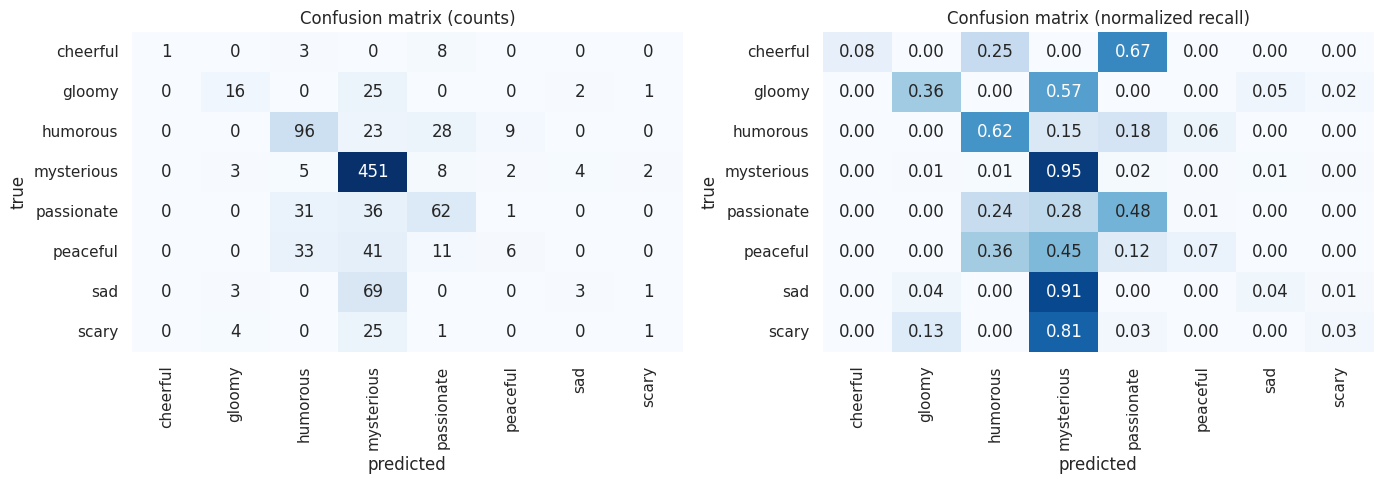

In [11]:
cm_labels = clf_results['confusion_matrix']['labels']
cm = np.array(clf_results['confusion_matrix']['matrix'])
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], cbar=False)
axes[0].set_title('Confusion matrix (counts)')
axes[0].set_xlabel('predicted'); axes[0].set_ylabel('true')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], cbar=False)
axes[1].set_title('Confusion matrix (normalized recall)')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('true')
plt.tight_layout()
plt.show()


### Feature Importances

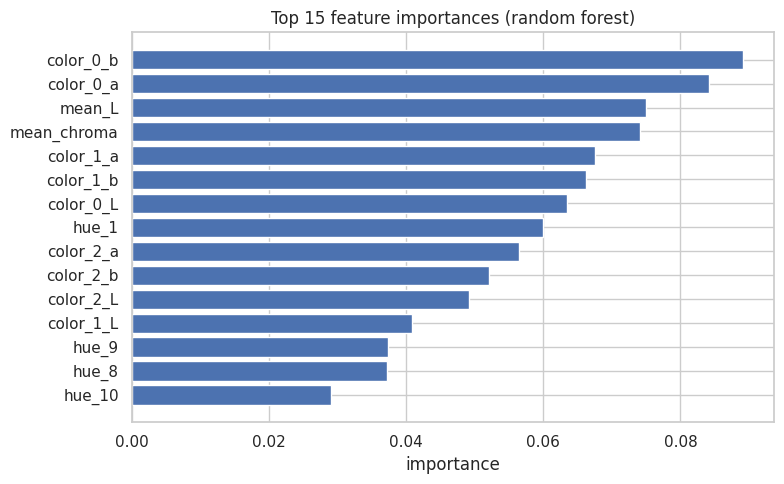

In [12]:
imp_df = pd.DataFrame(clf_results['feature_importances'])
top = imp_df.head(15)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'][::-1], top['importance'][::-1])
ax.set_title('Top 15 feature importances (random forest)')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()


### Kruskal-Wallis Per-Feature Significance

In [13]:
anova_results = run_anova(features, mood_labels)
anova_df = pd.DataFrame(anova_results).T.sort_values('statistic', ascending=False)
anova_df['significant'] = anova_df['p_value'] < 0.05
anova_df


,statistic,p_value,test,significant
hue_1,372.943634,0.0,kruskal_wallis,True
hue_8,224.055813,0.0,kruskal_wallis,True
mean_chroma,202.345443,0.0,kruskal_wallis,True
hue_9,196.509668,0.0,kruskal_wallis,True
mean_L,122.87306,0.0,kruskal_wallis,True
hue_7,77.701194,0.0,kruskal_wallis,True
hue_6,68.000627,0.0,kruskal_wallis,True
hue_11,66.474362,0.0,kruskal_wallis,True
hue_0,63.326973,0.0,kruskal_wallis,True
hue_10,58.990593,0.0,kruskal_wallis,True
